# End-to-end validation

Does the story actually **work** — against a real SQL Server, a published API
and HTTP probes — as opposed to merely compiling and passing its own unit
tests? Read from `E2EResults/`.

Unit tests pass by construction: the pipeline does not stop until they are
green. The same is true here of the *final* e2e run, so this notebook scores
the **path** — how many executions the model needed before the story first
worked end to end, and how often the harness itself was the thing that broke.


In [1]:
STORY_ID = "CPD-LC-001-003"


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
# Clear the per-session label cache and warning list first: re-running this
# cell after dropping new results into the trees would otherwise reuse stale
# model labels and count the same load warning once per re-run.
tdd.reset_caches()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
if not MODELS:
    print(f"no results found for {STORY_ID!r}; stories present in the result "
          f"trees: {tdd.discover_stories()}")
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")


story: CPD-LC-001-003 | models: ['Kimi-K2.5', 'Qwen3.7-max']
palette: {'Kimi-K2.5': '#2a78d6', 'Qwen3.7-max': '#1baf7a'}


## Data integrity gate

Identity drift, evidence and metric signal, checked before the charts.


In [3]:
summ = tdd.iteration_summary(STORY_ID, data)
sig = tdd.discrimination(summ)
drift = tdd.audit_identity(STORY_ID)
dead = sig[sig["status"].isin(["ABSENT", "ALL-NA", "CONSTANT"])]
e2e = data["e2e"]
print(f"identity : {len(drift)} disagreements, "
      f"{(~drift['reconciles']).sum() if not drift.empty else 0} unreconcilable")
print(f"e2e      : {len(e2e)} executions across "
      f"{e2e.groupby(['model', 'iteration']).ngroups if not e2e.empty else 0} runs")
print(f"signal   : {len(sig) - len(dead)}/{len(sig)} metrics discriminate")
if not dead.empty:
    display(dead)


identity : 0 disagreements, 0 unreconcilable
e2e      : 33 executions across 12 runs
signal   : 21/24 metrics discriminate


,metric,family,provenance,status,distinct,na_share
3,e2e_probe_pass_rate,B behavioural,tool-measured,CONSTANT,1,0.000
19,layer_balance,V verification,tool-measured,CONSTANT,1,0.083
20,layer_coverage,V verification,tool-measured,CONSTANT,1,0.083


## Outcome vs path

The left panel is the metric that looks obvious and says nothing: the status of
each run's **final** e2e execution. The right panel is the same data counted
over **every** execution. If the left is uniformly green while the right is
not, the pipeline's stopping rule — not the model — is what you are reading.

**Chart columns** — left: share of runs whose final e2e execution succeeded,
per model; right: outcome composition across all executions (`success` /
`failure`), same colors as elsewhere for run status.


final runs succeeded: 12/12  |  all executions succeeded: 13/33


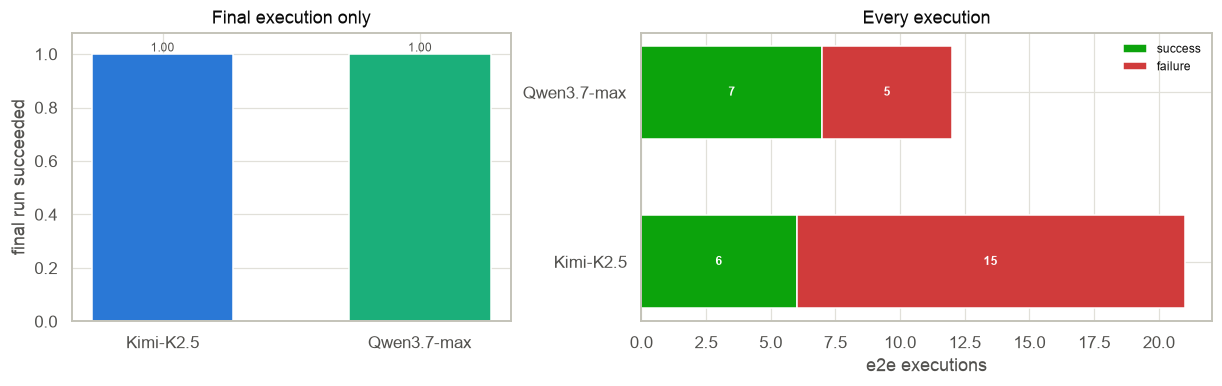

In [4]:
if e2e.empty:
    print("No e2e results for this story.")
else:
    fin = tdd.finals(e2e)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4),
                             gridspec_kw={"width_ratios": [1, 1.3]})

    rate = (fin.assign(ok=fin["status"].eq("success"))
               .groupby("model")["ok"].mean().reindex(HUE))
    bars = axes[0].bar(range(len(rate)), rate.values,
                       color=[PAL[m] for m in rate.index], width=0.55)
    axes[0].bar_label(bars, fmt="%.2f", fontsize=8, color=tdd.INK["secondary"])
    axes[0].set_xticks(range(len(rate)), rate.index)
    axes[0].set_ylim(0, 1.08)
    axes[0].set_ylabel("final run succeeded")
    axes[0].set_title("Final execution only")

    comp = (e2e.assign(outcome=np.where(e2e["status"].eq("success"), "success", "failure"))
               .groupby(["model", "outcome"]).size().unstack(fill_value=0)
               .reindex(HUE).fillna(0))
    left = np.zeros(len(comp))
    for outcome, color in (("success", tdd.STAGE_STATUS_COLORS["success"]),
                           ("failure", tdd.STAGE_STATUS_COLORS["failure"])):
        if outcome not in comp:
            continue
        axes[1].barh(comp.index, comp[outcome], left=left, color=color,
                     label=outcome, height=0.55)
        for y, (v, l) in enumerate(zip(comp[outcome], left)):
            if v:
                axes[1].text(l + v / 2, y, int(v), ha="center", va="center",
                             fontsize=8, color="white", fontweight="bold")
        left = left + comp[outcome].to_numpy()
    axes[1].set_xlabel("e2e executions")
    axes[1].set_title("Every execution")
    axes[1].legend(fontsize=8)

    print(f"final runs succeeded: {int(fin['status'].eq('success').sum())}/{len(fin)}"
          f"  |  all executions succeeded: "
          f"{int(e2e['status'].eq('success').sum())}/{len(e2e)}")


## Attempts until the story first worked

The behavioural equivalent of "attempts to green": how many e2e executions the
model needed before the feature passed against a live stack. This is the
B-family metric that carries the signal the outcome cannot.

**Chart & table columns** — chart: `e2e attempts to first pass` per iteration
(bar), lower is better; 1 means it worked the first time. Table:
`e2e_execs` (all executions), `e2e_attempts_to_pass`, `e2e_probe_depth`
(probes in the final run), `e2e_probe_pass_rate` and `e2e_infra_failures`.


,model,iteration,e2e_execs,e2e_attempts_to_pass,e2e_probe_depth,e2e_probe_pass_rate,e2e_infra_failures
0,Kimi-K2.5,1,3,3,1,1.0,0
1,Kimi-K2.5,2,6,6,1,1.0,2
2,Kimi-K2.5,3,4,4,1,1.0,0
3,Kimi-K2.5,4,1,1,1,1.0,0
4,Kimi-K2.5,5,5,5,1,1.0,0
5,Kimi-K2.5,6,2,2,1,1.0,0
6,Qwen3.7-max,1,2,1,1,1.0,0
7,Qwen3.7-max,2,2,2,2,1.0,0
8,Qwen3.7-max,3,3,3,2,1.0,0
9,Qwen3.7-max,4,1,1,1,1.0,0


mean attempts to first pass: {'Kimi-K2.5': 3.5, 'Qwen3.7-max': 1.83}


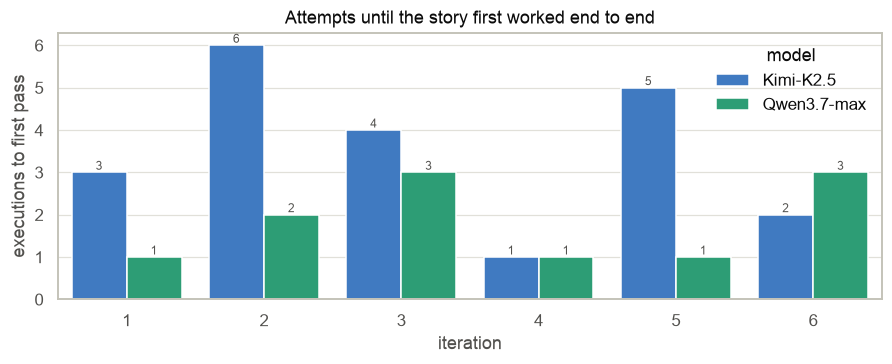

In [5]:
ep = summ[["model", "iteration", "e2e_execs", "e2e_attempts_to_pass",
           "e2e_probe_depth", "e2e_probe_pass_rate", "e2e_infra_failures"]].copy()
if ep.empty or ep["e2e_execs"].isna().all():
    print("No e2e results for this story.")
else:
    fig, ax = plt.subplots(figsize=(8, 3.2))
    sns.barplot(data=ep, x="iteration", y="e2e_attempts_to_pass", hue="model",
                hue_order=HUE, palette=PAL, errorbar=None, ax=ax)
    ax.set_ylabel("executions to first pass")
    ax.set_title("Attempts until the story first worked end to end")
    tdd.label_bars(ax, fmt="%.0f")

    display(ep.round(3).sort_values(["model", "iteration"]).reset_index(drop=True))
    mean_by_model = ep.groupby("model")["e2e_attempts_to_pass"].mean().round(2)
    print("mean attempts to first pass:", mean_by_model.to_dict())


## Probe depth — self-verification, not correctness

The probes are written by the agent, so their *count* measures how thoroughly
a model chose to verify its own work, not whether the work is right. It is
reported and tagged `self-reported` in `tdd.METRIC_CATALOG`, and never folded
into a score: a model can raise this number at will.

Read it against the pass rate. Deep probes that all pass is a strong signal;
a single shallow probe that passes is close to no evidence at all.

**Chart columns** — x: `probes in the final run`; y: `probe pass rate`; color:
model; point size: e2e executions needed. The dashed line marks a full pass.


,min,max,mean
model,,,
Kimi-K2.5,1,1,1.00
Qwen3.7-max,1,2,1.33


probe counts are agent-authored: treat depth as effort, not correctness


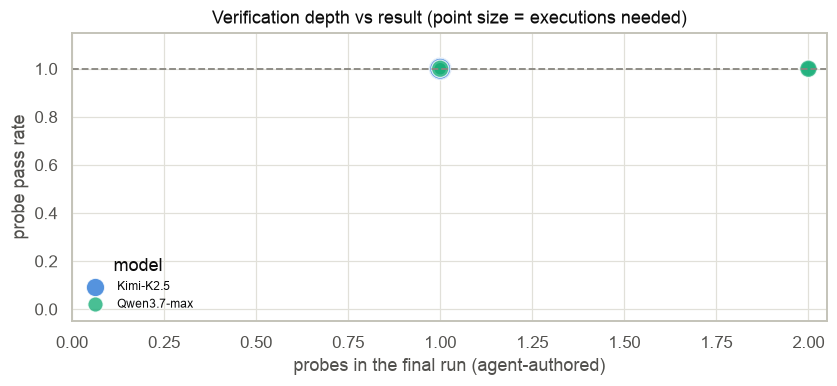

In [6]:
if ep.empty or ep["e2e_probe_depth"].isna().all():
    print("No e2e probe data for this story.")
else:
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    for model, g in ep.groupby("model"):
        ax.scatter(g["e2e_probe_depth"], g["e2e_probe_pass_rate"],
                   s=40 + 30 * g["e2e_execs"].fillna(1), color=PAL[model],
                   alpha=0.8, label=model, edgecolor="white", linewidth=0.8)
    ax.axhline(1.0, ls="--", lw=1.2, color=tdd.INK["muted"])
    ax.set_xlabel("probes in the final run (agent-authored)")
    ax.set_ylabel("probe pass rate")
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlim(left=0)
    ax.set_title("Verification depth vs result (point size = executions needed)")
    ax.legend(fontsize=8, title="model")

    depth = ep.groupby("model")["e2e_probe_depth"].agg(["min", "max", "mean"]).round(2)
    display(depth)
    print("probe counts are agent-authored: treat depth as effort, not correctness")


## Harness reliability

Separates "the code is wrong" from "the environment fell over". An execution
where the API never started tells you nothing about the model, so it is
tracked apart and excluded from behavioural credit.

**Chart & table columns** — chart: executions per run split into `API came up`
and `API never started`. Table: per-run counts plus `n_errors` recorded by the
e2e harness.


,model,iteration,API came up,API never started,n_errors
0,Kimi-K2.5,1,3,0,2
1,Kimi-K2.5,2,4,2,5
2,Kimi-K2.5,3,4,0,3
3,Kimi-K2.5,4,1,0,0
4,Kimi-K2.5,5,5,0,4
5,Kimi-K2.5,6,2,0,1
6,Qwen3.7-max,1,2,0,0
7,Qwen3.7-max,2,2,0,1
8,Qwen3.7-max,3,3,0,2
9,Qwen3.7-max,4,1,0,0


4/33 executions never got the API up — these carry no behavioural signal


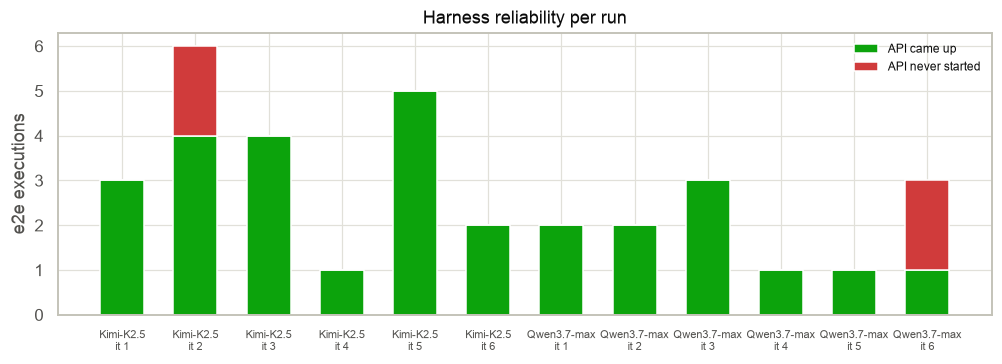

In [7]:
if e2e.empty:
    print("No e2e results for this story.")
else:
    infra = (e2e.assign(up=np.where(e2e["backend_up"], "API came up",
                                    "API never started"))
                .groupby(["model", "iteration", "up"]).size()
                .unstack(fill_value=0).reset_index())
    for col in ("API came up", "API never started"):
        if col not in infra:
            infra[col] = 0

    fig, ax = plt.subplots(figsize=(9, 3.2))
    labels = [f"{m}\nit {i}" for m, i in zip(infra["model"], infra["iteration"])]
    x = np.arange(len(infra))
    ax.bar(x, infra["API came up"], color=tdd.STAGE_STATUS_COLORS["success"],
           label="API came up", width=0.6)
    ax.bar(x, infra["API never started"], bottom=infra["API came up"],
           color=tdd.STAGE_STATUS_COLORS["failure"], label="API never started",
           width=0.6)
    ax.set_xticks(x, labels, fontsize=7)
    ax.set_ylabel("e2e executions")
    ax.set_title("Harness reliability per run")
    ax.legend(fontsize=8)

    errs = e2e.groupby(["model", "iteration"])["n_errors"].sum().reset_index()
    display(infra.merge(errs, on=["model", "iteration"]))
    n_down = int((~e2e["backend_up"]).sum())
    print(f"{n_down}/{len(e2e)} executions never got the API up "
          f"— these carry no behavioural signal")


## Sanity checks


In [8]:
if not e2e.empty:
    assert e2e.groupby(["story", "model", "iteration", "ts"]).size().max() == 1, \
        "one e2e summary per execution"
    assert (e2e["probes_passed"] <= e2e["total_probes"]).all(), \
        "passed probes cannot exceed the total"
    assert e2e["model"].isin(HUE).all(), "identity drift leaked into the e2e frame"
assert summ["model"].isin(HUE).all(), "identity drift leaked into the master table"
assert drift.empty or drift["reconciles"].all(), "misfiled results present"
if not ep.empty and ep["e2e_probe_pass_rate"].notna().any():
    assert ep["e2e_probe_pass_rate"].dropna().between(0, 1).all()
print(f"sanity checks passed | {len(tdd.load_warnings)} load warnings | "
      f"{len(dead)} metrics without signal")


sanity checks passed | 0 load warnings | 3 metrics without signal
